In [1]:
# %run validation.py --explanation_type=Self --seed=42

In [2]:

# from load_experiment_data import (
#     train_dataset_name,
#     test_dataset_name,
#     train_dataset_split,
#     test_dataset_split,
#     load_data_and_estimators,
#     explanation_types,
#     linear_coders,
#     explanation_seed,
#     explanation_k
# )
# train_dataset, test_dataset, estimators = load_data_and_estimators()

In [3]:
# from explanations import TopKMostInfluential,TopKLeastInfluential

In [4]:
# explanation = TopKMostInfluential(99,estimators[0],k=10)
# explanation.documents

In [5]:
# explanation.description

In [6]:
# train_dataset.select(explanation.documents)["messages"]

In [7]:
# train_dataset.select([explanation.document_idx])["messages"]

In [8]:
# TopKMostInfluential(1,estimators[1],k=10).documents

In [9]:
# trd6i7fogizöul

In [10]:
%run merge_results.py

Loading cache/validation/partial
Merging cache/validation/partial
Saved to results/validation


In [11]:
import os
from multiprocess import set_start_method
set_start_method("spawn")
import logging
logger = logging.getLogger("ignite.handlers.early_stopping.EarlyStopping")
logger.setLevel(logging.WARNING)

In [12]:



import os
import torch

import argparse



In [13]:
# from load_experiment_data import (
#     train_dataset_name,
#     test_dataset_name,
#     train_dataset_split,
#     test_dataset_split,
#     load_data_and_estimators,
#     explanation_types,
#     linear_coders,
#     explanation_seed,
#     explanation_k
# )
# # train_dataset, test_dataset, estimators = load_data_and_estimators()


In [14]:
# from functools import partial
# from explanations import KRandom
# k_random_types = [partial(KRandom, seed=s) for s in range(9)]
# explanation_types = explanation_types + k_random_types

In [15]:
# import logging
# from concurrent.futures import ProcessPoolExecutor, as_completed
# import torch
# import multiprocessing
# from tqdm import tqdm
# import itertools
# import pandas as pd
# import traceback

# logging.basicConfig(level=logging.ERROR, format='%(asctime)s [%(levelname)s] %(message)s')
# multiprocessing.set_start_method('spawn', force=True)
# torch.manual_seed(42)




# num_devices = torch.cuda.device_count()







In [16]:
import glob
import pandas as pd
import os

In [17]:
import pyarrow as pa
import pyarrow.parquet as pq

In [18]:
df_validation = pq.ParquetDataset("results/validation").read().to_pandas()


In [19]:
# df_scoring = merge_fragments_with_source_column_parallel( source_dir="cache/scoring/partial", target_dir="results/scoring")
# df_scoring["linear_coder"] = df_scoring["source_file"].apply(lambda path: os.path.basename(os.path.dirname(os.path.dirname(path))))

In [20]:
# df_scoring = load_or_merge_dataset( source_dir="cache/scoring/partial", target_dir="cache/scoring/full")
# df_scoring["linear_coder"] = df_scoring["source_file"].apply(lambda path: os.path.basename(os.path.dirname(os.path.dirname(path))))

In [21]:
# df_scoring = load_or_merge_dataset(
#     source_dir="cache/scoring/partial",
#     target_dir="cache/scoring/full"
# )


# df_scoring["linear_coder"] = df_scoring["source_file"].apply(
#     lambda path: os.path.basename(os.path.dirname(os.path.dirname(path)))
# )

In [22]:
import re

In [23]:
import re

def extract_k(explanation_type):
    if "The test instance (as a sanity check)" in explanation_type:
        return 1
    top_match = re.search(r"Top-(\d+)", explanation_type)
    if top_match:
        return int(top_match.group(1))
    random_match = re.search(r"(\d+)\s+random examples", explanation_type)
    if random_match:
        return int(random_match.group(1))
    return None

df_validation["k"] = df_validation["explanation_type"].apply(extract_k)
import re

def replace_k_with_X(explanation_type):

    explanation_type = re.sub(r"Top-(\d+)", "Top-X", explanation_type)

    explanation_type = re.sub(r"(\d+)\s+random examples", "X random examples", explanation_type)
    return explanation_type



In [24]:
df_validation_random = df_validation[df_validation["explanation_type"].str.contains("random examples with seed")]
df_validation_selection = df_validation[~df_validation["explanation_type"].str.contains("random examples with seed")]


In [26]:
r = pd.merge(
                df_validation_selection,
                df_validation_random,
                on=[
                    "model",
                    "estimator",
                    "train_dataset",
                    "train_split",
                    "test_dataset",
                    "test_split",
                    "k",
                    "document_idx"
                ],
                suffixes=("_selection", "_random"),
                how="inner"
            )
r["validation_score_log_p"] = r["delta_log_p_selection"] >= r["delta_log_p_random"]
r["validation_score_jsd"] = r["jsd_selection"] >= r["jsd_random"]
r["validation_score_kld"] = r["kld(before||after)_selection"] >= r["kld(before||after)_random"]
r_summary = r.groupby([         "estimator",
                     "explanation_type_selection",
                    "model",
                    "train_dataset",
                    "train_split",
                    "test_dataset",
                    "test_split",
                    "k",
                ]).agg(
                    mean_validation_score_log_p=("validation_score_log_p", "mean"),
                    count_validation_score_log_p=("validation_score_log_p", "count"),
                    mean_validation_score_jsd=("validation_score_jsd", "mean"),
                    count_validation_score_jsd=("validation_score_jsd", "count"),
                    mean_validation_score_kld=("validation_score_kld", "mean"),
                    count_validation_score_kld=("validation_score_kld", "count")
                    )
r_summary


mean_validation_score_log_p  \
estimator                                  explanation_type_selection                         model                                              train_dataset                                train_split test_dataset                                 test_split k                                 
BM25Estimator: k1=1.5, b=0.75              The test instance (as a sanity check)              OLMo-2-0425-1B_tulu-3-sft-olmo-2-mixture-0225_l... loris3/tulu-3-sft-olmo-2-mixture-0225-sample train       loris3/tulu-3-sft-olmo-2-mixture-0225-sample test       1                      0.944444   
                                           Top-1 least influential (scores closest to zero)   OLMo-2-0425-1B_tulu-3-sft-olmo-2-mixture-0225_l... loris3/tulu-3-sft-olmo-2-mixture-0225-sample train       loris3/tulu-3-sft-olmo-2-mixture-0225-sample test       1                      0.576923   
                                           Top-1 most harmful (most positive scores)          OLMo-2-0425-1B_tulu-3-sft-olmo-2-mixture-0225_l... loris3/tulu-3-sft-olmo-2-mixture-0225-sample train       loris3/tulu-3-sft-olmo-2-mixture-0225-sample test       1                      0.588235   
                                           Top-1 most helpful (most negative scores)          OLMo-2-0425-1B_tulu-3-sft-olmo-2-mixture-0225_l... loris3/tulu-3-sft-olmo-2-mixture-0225-sample train       loris3/tulu-3-sft-olmo-2-mixture-0225-sample test       1                      0.500000   
                                           Top-1 most influential (scores with largest abs... OLMo-2-0425-1B_tulu-3-sft-olmo-2-mixture-0225_l... loris3/tulu-3-sft-olmo-2-mixture-0225-sample train       loris3/tulu-3-sft-olmo-2-mixture-0225-sample test       1                      0.611111   
DataInfEstimator: fast_implementation=True The test instance (as a sanity check)              OLMo-2-0425-1B_tulu-3-sft-olmo-2-mixture-0225_l... loris3/tulu-3-sft-olmo-2-mixture-0225-sample train       loris3/tulu-3-sft-olmo-2-mixture-0225-sample test       1                      0.938272   
                                           Top-1 least influential (scores closest to zero)   OLMo-2-0425-1B_tulu-3-sft-olmo-2-mixture-0225_l... loris3/tulu-3-sft-olmo-2-mixture-0225-sample train       loris3/tulu-3-sft-olmo-2-mixture-0225-sample test       1                      0.555556   
                                           Top-1 most harmful (most positive scores)          OLMo-2-0425-1B_tulu-3-sft-olmo-2-mixture-0225_l... loris3/tulu-3-sft-olmo-2-mixture-0225-sample train       loris3/tulu-3-sft-olmo-2-mixture-0225-sample test       1                      0.555556   
                                           Top-1 most helpful (most negative scores)          OLMo-2-0425-1B_tulu-3-sft-olmo-2-mixture-0225_l... loris3/tulu-3-sft-olmo-2-mixture-0225-sample train       loris3/tulu-3-sft-olmo-2-mixture-0225-sample test       1                      0.641975   
                                           Top-1 most influential (scores with largest abs... OLMo-2-0425-1B_tulu-3-sft-olmo-2-mixture-0225_l... loris3/tulu-3-sft-olmo-2-mixture-0225-sample train       loris3/tulu-3-sft-olmo-2-mixture-0225-sample test       1                      0.530864   
LESSEstimator: normalize=True              The test instance (as a sanity check)              OLMo-2-0425-1B_tulu-3-sft-olmo-2-mixture-0225_l... loris3/tulu-3-sft-olmo-2-mixture-0225-sample train       loris3/tulu-3-sft-olmo-2-mixture-0225-sample test       1                      0.978000   
                                           Top-1 least influential (scores closest to zero)   OLMo-2-0425-1B_tulu-3-sft-olmo-2-mixture-0225_l... loris3/tulu-3-sft-olmo-2-mixture-0225-sample train       loris3/tulu-3-sft-olmo-2-mixture-0225-sample test       1                      0.504200   
                                           Top-1 most harmful (most positive scores)          OLMo-2-0425-1B_tulu-3-sft-olmo-2-mixture-0225_l... loris3/tulu-3-s

In [30]:
r_summary.sort_values(by="mean_validation_score_log_p", ascending=False)

mean_validation_score_log_p  \
estimator                                  explanation_type_selection                         model                                              train_dataset                                train_split test_dataset                                 test_split k                                 
LESSEstimator: normalize=True              The test instance (as a sanity check)              OLMo-2-0425-1B_tulu-3-sft-olmo-2-mixture-0225_l... loris3/tulu-3-sft-olmo-2-mixture-0225-sample train       loris3/tulu-3-sft-olmo-2-mixture-0225-sample test       1                      0.978000   
BM25Estimator: k1=1.5, b=0.75              The test instance (as a sanity check)              OLMo-2-0425-1B_tulu-3-sft-olmo-2-mixture-0225_l... loris3/tulu-3-sft-olmo-2-mixture-0225-sample train       loris3/tulu-3-sft-olmo-2-mixture-0225-sample test       1                      0.944444   
DataInfEstimator: fast_implementation=True The test instance (as a sanity check)              OLMo-2-0425-1B_tulu-3-sft-olmo-2-mixture-0225_l... loris3/tulu-3-sft-olmo-2-mixture-0225-sample train       loris3/tulu-3-sft-olmo-2-mixture-0225-sample test       1                      0.938272   
                                           Top-1 most helpful (most negative scores)          OLMo-2-0425-1B_tulu-3-sft-olmo-2-mixture-0225_l... loris3/tulu-3-sft-olmo-2-mixture-0225-sample train       loris3/tulu-3-sft-olmo-2-mixture-0225-sample test       1                      0.641975   
BM25Estimator: k1=1.5, b=0.75              Top-1 most influential (scores with largest abs... OLMo-2-0425-1B_tulu-3-sft-olmo-2-mixture-0225_l... loris3/tulu-3-sft-olmo-2-mixture-0225-sample train       loris3/tulu-3-sft-olmo-2-mixture-0225-sample test       1                      0.611111   
                                           Top-1 most harmful (most positive scores)          OLMo-2-0425-1B_tulu-3-sft-olmo-2-mixture-0225_l... loris3/tulu-3-sft-olmo-2-mixture-0225-sample train       loris3/tulu-3-sft-olmo-2-mixture-0225-sample test       1                      0.588235   
                                           Top-1 least influential (scores closest to zero)   OLMo-2-0425-1B_tulu-3-sft-olmo-2-mixture-0225_l... loris3/tulu-3-sft-olmo-2-mixture-0225-sample train       loris3/tulu-3-sft-olmo-2-mixture-0225-sample test       1                      0.576923   
DataInfEstimator: fast_implementation=True Top-1 least influential (scores closest to zero)   OLMo-2-0425-1B_tulu-3-sft-olmo-2-mixture-0225_l... loris3/tulu-3-sft-olmo-2-mixture-0225-sample train       loris3/tulu-3-sft-olmo-2-mixture-0225-sample test       1                      0.555556   
                                           Top-1 most harmful (most positive scores)          OLMo-2-0425-1B_tulu-3-sft-olmo-2-mixture-0225_l... loris3/tulu-3-sft-olmo-2-mixture-0225-sample train       loris3/tulu-3-sft-olmo-2-mixture-0225-sample test       1                      0.555556   
LESSEstimator: normalize=True              Top-25 most helpful (most negative scores)         OLMo-2-0425-1B_tulu-3-sft-olmo-2-mixture-0225_l... loris3/tulu-3-sft-olmo-2-mixture-0225-sample train       loris3/tulu-3-sft-olmo-2-mixture-0225-sample test       25                     0.543000   
DataInfEstimator: fast_implementation=True Top-1 most influential (scores with largest abs... OLMo-2-0425-1B_tulu-3-sft-olmo-2-mixture-0225_l... loris3/tulu-3-sft-olmo-2-mixture-0225-sample train       loris3/tulu-3-sft-olmo-2-mixture-0225-sample test       1                      0.530864   
LESSEstimator: normalize=True              Top-25 most harmful (most positive scores)         OLMo-2-0425-1B_tulu-3-sft-olmo-2-mixture-0225_l... loris3/tulu-3-sft-olmo-2-mixture-0225-sample train       loris3/tulu-3-sft-olmo-2-mixture-0225-sample test       25                     0.516600   
                                           Top-25 most influential (scores with largest ab... OLMo-2-0425-1B_tulu-3-sft-olmo-2-mixture-0225_l... loris3/tulu-3-s

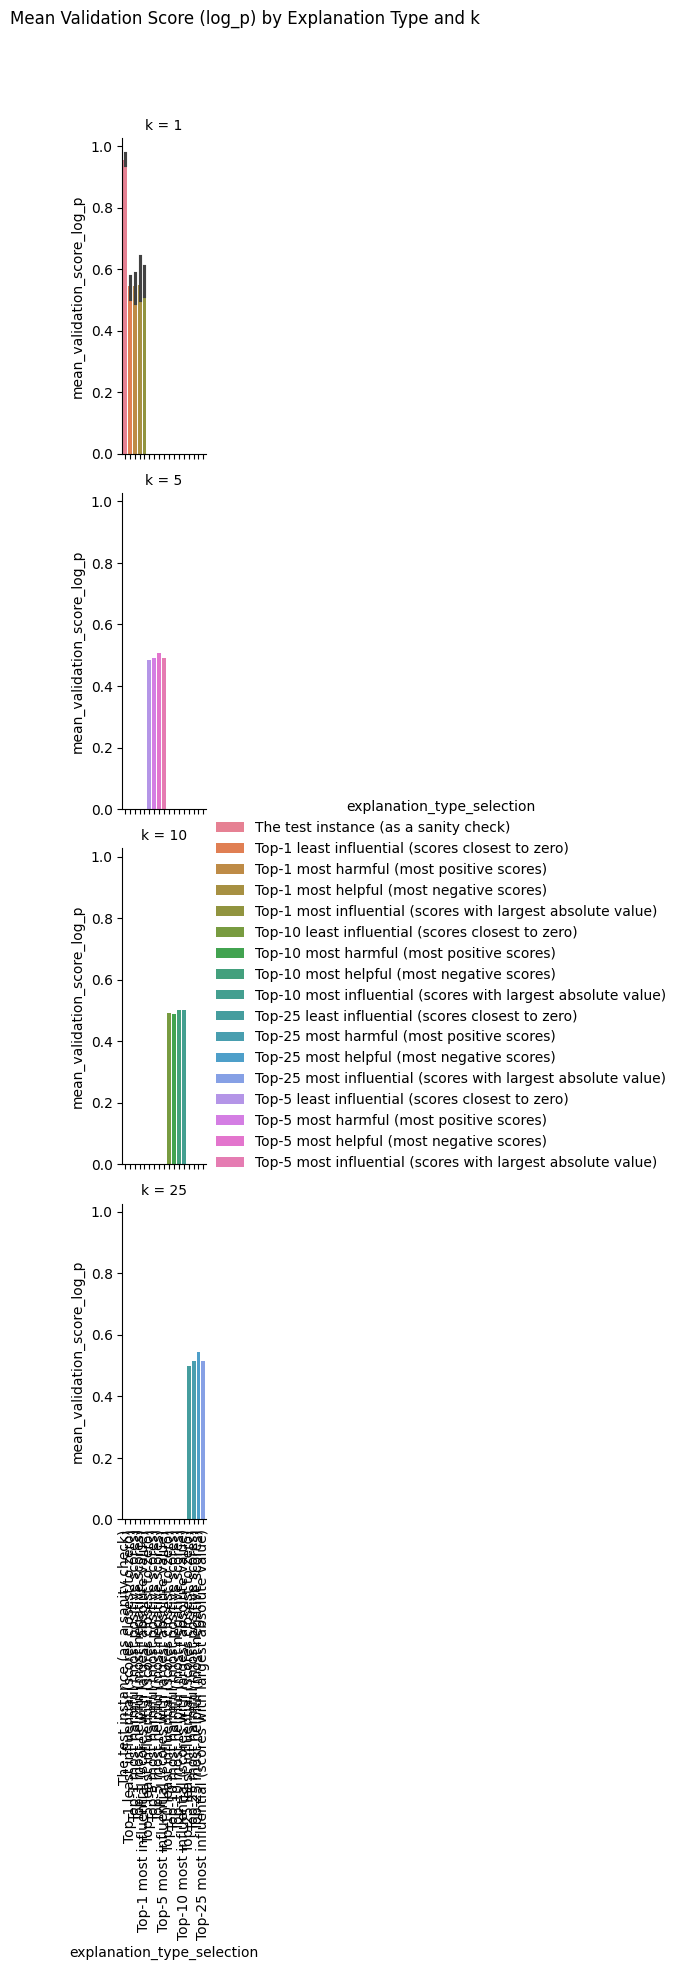

In [28]:
import matplotlib.pyplot as plt
import seaborn as sns

g = sns.FacetGrid(
    r_summary.reset_index(),
    row="k",
    hue="explanation_type_selection",
    sharey=True,
    height=4
)


g.map_dataframe(
    sns.barplot,
    x="explanation_type_selection",
    y="mean_validation_score_log_p"
)
for ax in g.axes.flat:
    plt.setp(ax.get_xticklabels(), rotation=90) 
g.add_legend()
g.set_titles(row_template="k = {row_name}")
g.fig.subplots_adjust(top=0.9)
g.fig.suptitle("Mean Validation Score (log_p) by Explanation Type and k")
plt.show()

In [29]:
assert df_validation_random["explanation_type"].nunique() == (len(explanation_k) * (len(explanation_seed)))

NameError: name 'explanation_k' is not defined

In [ ]:
df_validation_selections["explanation_type"].nunique()

In [ ]:
df_validation_selections["explanation_type"].unique()

In [ ]:
(len(explanation_k) * (len(explanation_types)))+1

In [ ]:
explanation_k

In [ ]:
df_validation_random["explanation_type"].unique()

In [ ]:
ghifjo0dvo

In [ ]:
df_validation_random = df_validation[df_validation["explanation_type"].str.contains("random")]
# df_validation_random = df_validation_random.drop(columns=["indices_trained_on"])
df_validation_selections = df_validation[~df_validation["explanation_type"].str.contains("random")]
df_validation_selections = df_validation_selections.drop(columns=["indices_trained_on"])




In [ ]:
# df_scoring_random = df_scoring[df_scoring["explanation_type"].str.contains("random")]
# # df_scoring_random = df_scoring_random.drop(columns=["indices_trained_on"])
# df_scoring_selections = df_scoring[~df_scoring["explanation_type"].str.contains("random")]
# # df_scoring_selections = df_scoring_selections.drop(columns=["indices_trained_on"])

In [ ]:
# df_scoring_random[df_scoring_random["explanation_type"] == "1 random examples with seed 42"]["mse"].mean()

In [ ]:
df_validation_selections.groupby("explanation_type").count()

In [ ]:
df_validation_selections.groupby("explanation_type").nunique()

In [ ]:
df_validation_random = df_validation_random.drop(columns=["indices_trained_on"])
df_validation_random

In [ ]:
import re
import pandas as pd

pattern = r"Top-(\d+)"
group_cols = [
    "model",
    "estimator",
    "train_dataset",
    "train_split",
    "test_dataset",
    "test_split",
    # "LESSEstimator: normalize",
    "document_idx"
]

results = []
for linear_coder in linear_coders:
    linear_coder = linear_coder.__name__
    for explanation_type in df_validation_selections["explanation_type"].unique():
        k = int(re.match(pattern, explanation_type).group(1)) if "The test instance (as a sanity check)" not in explanation_type else 1

        # Only random runs matching this k
        random_run_names = df_validation_random[
            df_validation_random["explanation_type"].str.contains(f"{k} random")
        ]["explanation_type"].unique()

        for random_run_name in random_run_names:

            # Filter and drop duplicate rows per document
            sel = df_validation_selections[(df_validation_selections["explanation_type"] == explanation_type)]
            rnd = df_validation_random[(df_validation_random["explanation_type"] == random_run_name)]
            scores_sel = df_scoring_selections[(df_scoring_selections["explanation_type"] == explanation_type) & (df_scoring_selections["linear_coder"] == linear_coder)]
            scores_rnd = df_scoring_random[(df_scoring_random["explanation_type"] == random_run_name) &(df_scoring_random["linear_coder"] == linear_coder)]

            # Merge selection and random results on group_cols
            r = pd.merge(
                sel,
                rnd,
                on=group_cols,
                suffixes=("_selection", "_random"),
                how="inner"
            )

            # Merge pred_gain columns
            r = pd.merge(
                r,
                scores_sel[group_cols + ["pred_gain", "mse"]].rename(columns={"pred_gain": "pred_gain_selection","mse": "mse_selection"}),
                on=group_cols,
                how="left"
            )
            r = pd.merge(
                r,
                scores_rnd[group_cols + ["pred_gain","mse"]].rename(columns={"pred_gain": "pred_gain_random", "mse": "mse_random"}),
                on=group_cols,
                how="left"
            )



            if len(r) == 0:
                continue
            # display(r[[col for col in r.columns if col != 'indices_trained_on']].nunique())
            # display(r[[col for col in r.columns if col != 'indices_trained_on']].count())
            # display(len(scores_sel))
            # display(scores_sel[group_cols + ["pred_gain", "mse"]].rename(columns={"pred_gain": "pred_gain_selection","mse": "mse_selection"}).count())
            # raise Error

            # Compute summary statistics per random run
            results.append({
                "linear_coder": linear_coder,
                "explanation_type": explanation_type,
                "random_run": random_run_name,
                "k": k,
                "validation_score": (r["delta_target_document_selection"] >= r["delta_target_document_random"]).mean(skipna=True),
                "pred_gain_selection": r["pred_gain_selection"].mean(skipna=True),
                "pred_gain_random": r["pred_gain_random"].mean(skipna=True),
                "mse_selection": r["mse_selection"].mean(skipna=True),
                "mse_random": r["mse_random"].mean(skipna=True),
                "count": len(r),
                **r.iloc[0][[col for col in group_cols if col != "document_idx"]].to_dict(),
            })
            


results_df = pd.DataFrame(results)
results_df


In [ ]:
results_df.groupby(["linear_coder", "explanation_type","model","estimator"]).mean(numeric_only=True)

In [ ]:
from scipy.stats import ttest_rel

results = []

for (k, exp_type,linear_coder), group in results_df.groupby(['k', 'explanation_type', 'linear_coder']):
    # paired test: selection vs random
    t_stat, p_value = ttest_rel(group['validation_score'], group['pred_gain_random'], alternative='greater')
    results.append({'k': k,"linear_coder":linear_coder, 'explanation_type': exp_type, 't_stat': t_stat, 'p_value': p_value})

pd.DataFrame(results)



In [ ]:
from scipy.stats import wilcoxon
w_stat, p_value = wilcoxon(group['validation_score'], group['pred_gain_random'], alternative='greater')
w_stat

In [ ]:
p_value

In [ ]:
import statsmodels.api as sm
import statsmodels.formula.api as smf

# Drop NaNs
df = results_df.dropna(subset=["validation_score", "pred_gain_selection", "pred_gain_random"])

# Mixed-effects model
# 'random_run' is a grouping variable (random intercept)
# You can optionally include 'explanation_type' as another random effect
md = smf.mixedlm(
    "validation_score ~ pred_gain_selection + pred_gain_random",
    df,
    groups=df["random_run"]
)
mdf = md.fit()
print(mdf.summary())


In [ ]:
corr_selection = results_df['validation_score'].corr(results_df['pred_gain_selection'])
corr_random = results_df['validation_score'].corr(results_df['pred_gain_random'])

print(f"Correlation with pred_gain_selection: {corr_selection:.3f}")
print(f"Correlation with pred_gain_random: {corr_random:.3f}")


In [ ]:
import statsmodels.api as sm

# Validation score ~ pred_gain_selection
X1 = sm.add_constant(results_df['pred_gain_selection'])
model1 = sm.OLS(results_df['validation_score'], X1).fit()
print(model1.summary())

# Validation score ~ pred_gain_random
X2 = sm.add_constant(results_df['pred_gain_random'])
model2 = sm.OLS(results_df['validation_score'], X2).fit()
print(model2.summary())


In [ ]:
import statsmodels.api as sm
import pandas as pd

results = []

for keys, group in df.groupby(["explanation_type", "model", "estimator", "linear_coder"]):
    x = -pd.to_numeric(group["mse"], errors="coerce")  # negate MSE so lower is better
    y = pd.to_numeric(group["delta_target_document"], errors="coerce")
    
    mask = ~(x.isna() | y.isna())
    x_clean, y_clean = x[mask], y[mask]
    

    X = sm.add_constant(pd.DataFrame({"neg_mse": x_clean}))
    model = sm.OLS(y_clean, X).fit()
    
    results.append({
        "explanation_type": keys[0],
        "model": keys[1],
        "estimator": keys[2],
        "linear_coder": keys[3],
        "coef": model.params.get("neg_mse", None),       
        "p_value": model.pvalues.get("neg_mse", None),  
        "r_squared": model.rsquared
    })

results_df = pd.DataFrame(results)
results_df


In [ ]:
import statsmodels.api as sm

results = []


for keys, group in df.groupby(["explanation_type", "model", "estimator", "linear_coder"]):
    x = pd.to_numeric(group["pred_gain"], errors="coerce")
    y = pd.to_numeric(group["delta_target_document"], errors="coerce")
    
    mask = ~(x.isna() | y.isna())
    x_clean, y_clean = x[mask], y[mask]
    

    X = sm.add_constant(x_clean)
    model = sm.OLS(y_clean, X).fit()
    
    results.append({
        "explanation_type": keys[0],
        "model": keys[1],
        "estimator": keys[2],
        "linear_coder": keys[3],
        "coef": model.params.get("pred_gain", None),
        "p_value": model.pvalues.get("pred_gain", None),
        "r_squared": model.rsquared
    })


results_df = pd.DataFrame(results)
results_df
